# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**: Anne Mari Suenaga Sakai   -   **RA**: 822304

**Nome**: Felipe Jun Nishitani   -   **RA**: 822353

**Nome**: Lucas Pereira Goes   -   **RA**: 822938

In [70]:
# from google.colab import drive
# drive.mount('/content/drive')

---
## Visão geral

Este notebook desenvolve um sistema de categorização automática de documentos jurídicos do corpus VICTOR. O objetivo é classificar cada documento em uma das cinco categorias válidas:

| Rótulo | Categoria |
|---:|---|
| 0 | Acórdão |
| 1 | Agravo de Recurso Extraordinário (ARE) |
| 2 | Despacho |
| 3 | Recurso Extraordinário (RE) |
| 4 | Sentença |

As amostras com `Category = -1` são documentos sem rótulo. Elas serão tratadas por pseudo-rotulagem e não entrarão no conjunto de validação.


---
## 1. Análise exploratória

Esta seção examina a estrutura da base, a qualidade dos dados, o desbalanceamento, o tamanho dos documentos e o vocabulário jurídico. As contagens lexicais usam apenas uma normalização mínima interna; a transformação oficial dos textos é definida posteriormente na seção de pré-processamento.


In [71]:
# 1.1 Importações, configuração e leitura da base
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

RANDOM_STATE = 42
CLASSES_VALIDAS = [0, 1, 2, 3, 4]
MAPA_CLASSES = {
    0: "Acórdão",
    1: "Agravo de Recurso Extraordinário (ARE)",
    2: "Despacho",
    3: "Recurso Extraordinário (RE)",
    4: "Sentença",
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
warnings.filterwarnings("ignore", category=FutureWarning)

CAMINHO_TREINO = Path("train.csv")
CAMINHO_TESTE = Path("test.csv")
CAMINHO_SUBMISSION = Path("submission.csv")

if not CAMINHO_TREINO.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {CAMINHO_TREINO.resolve()}")

df = pd.read_csv(CAMINHO_TREINO)
df.head()


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera ...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimen...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o p...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazen...",3


In [72]:
# 1.2 Estrutura e significado dos atributos
descricao_atributos = pd.DataFrame({
    "Atributo": ["Id", "Body", "Category"],
    "Significado": [
        "Identificador único do documento.",
        "Texto extraído das páginas do documento jurídico.",
        "Rótulo da categoria; -1 indica amostra não rotulada.",
    ],
})

print(f"Dimensões da base: {df.shape[0]} linhas e {df.shape[1]} colunas")
display(descricao_atributos)
display(df.head())

print("\nTipos e preenchimento:")
df.info()


Dimensões da base: 22680 linhas e 3 colunas


,Atributo,Significado
0,Id,Identificador único do documento.
1,Body,Texto extraído das páginas do documento jurídico.
2,Category,Rótulo da categoria; -1 indica amostra não rot...


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera ...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimen...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o p...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazen...",3



Tipos e preenchimento:
<class 'pandas.DataFrame'>
RangeIndex: 22680 entries, 0 to 22679
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Id        22680 non-null  int64
 1   Body      22680 non-null  str  
 2   Category  22680 non-null  int64
dtypes: int64(2), str(1)
memory usage: 531.7 KB


In [73]:
# 1.3 Qualidade dos dados
diagnostico = pd.DataFrame({
    "valores_nulos": df.isna().sum(),
    "percentual_nulos": (100 * df.isna().mean()).round(2),
    "valores_unicos": df.nunique(dropna=False),
})

display(diagnostico)
print("IDs duplicados:", int(df["Id"].duplicated().sum()))
print("Textos duplicados:", int(df["Body"].duplicated().sum()))

grupos_texto = df.groupby("Body")["Category"].agg(["size", "nunique"])
print(
    "Grupos de texto repetido:",
    int((grupos_texto["size"] > 1).sum()),
)
print(
    "Grupos repetidos com rótulos conflitantes:",
    int((grupos_texto["nunique"] > 1).sum()),
)


,valores_nulos,percentual_nulos,valores_unicos
Id,0,0.0,22680
Body,0,0.0,11497
Category,0,0.0,6


IDs duplicados: 0
Textos duplicados: 11183
Grupos de texto repetido: 2514
Grupos repetidos com rótulos conflitantes: 884


,classe,quantidade,percentual
0,Recurso Extraordinário (RE),12876,56.77
1,Agravo de Recurso Extraordinário (ARE),3529,15.56
2,Sentença,2903,12.80
3,Não rotulado (-1),2268,10.00
4,Acórdão,665,2.93
5,Despacho,439,1.94


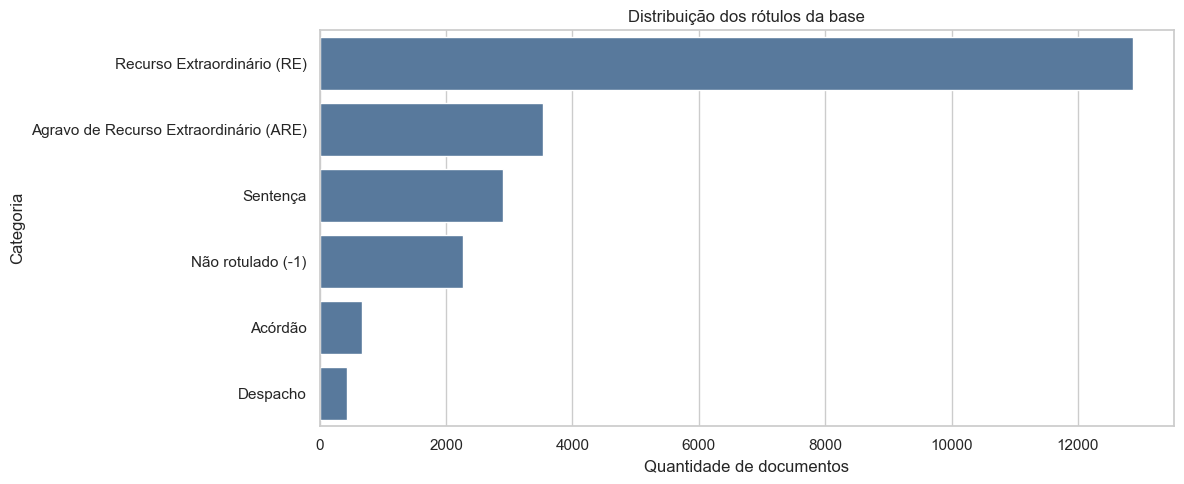

In [74]:
# 1.4 Distribuição dos rótulos, incluindo as amostras não rotuladas
df["Category_nome"] = df["Category"].map(MAPA_CLASSES).fillna("Não rotulado (-1)")

dist_classes = (
    df["Category_nome"]
    .value_counts(dropna=False)
    .rename_axis("classe")
    .reset_index(name="quantidade")
)
dist_classes["percentual"] = (
    100 * dist_classes["quantidade"] / len(df)
).round(2)

display(dist_classes)

plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    y="Category_nome",
    order=df["Category_nome"].value_counts().index,
    color="#4C78A8",
)
plt.title("Distribuição dos rótulos da base")
plt.xlabel("Quantidade de documentos")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()


In [75]:
# 1.5 Desbalanceamento entre as cinco classes válidas
contagens_validas = (
    df.loc[df["Category"].isin(CLASSES_VALIDAS), "Category"]
    .value_counts()
    .reindex(CLASSES_VALIDAS, fill_value=0)
)

razao_desbalanceamento = (
    contagens_validas.max() / contagens_validas[contagens_validas > 0].min()
)

display(
    contagens_validas.rename(index=MAPA_CLASSES)
    .rename("quantidade")
    .to_frame()
)
print(f"Razão entre a maior e a menor classe: {razao_desbalanceamento:.2f}")
print(
    "A avaliação priorizará Macro F1, pois essa métrica atribui o mesmo peso "
    "a cada classe, independentemente de sua frequência."
)


,quantidade
Category,
Acórdão,665
Agravo de Recurso Extraordinário (ARE),3529
Despacho,439
Recurso Extraordinário (RE),12876
Sentença,2903


Razão entre a maior e a menor classe: 29.33
A avaliação priorizará Macro F1, pois essa métrica atribui o mesmo peso a cada classe, independentemente de sua frequência.


,qtd_caracteres,qtd_palavras,qtd_sentencas
count,22680.000000,22680.000000,22680.0
mean,1758.236772,216.426058,0.0
std,750.062347,93.088142,0.0
min,4.000000,1.000000,0.0
25%,1293.000000,159.000000,0.0
50%,1715.000000,209.000000,0.0
75%,2177.000000,268.000000,0.0
90%,2678.000000,327.000000,0.0
95%,3067.000000,380.000000,0.0
99%,3684.000000,465.000000,0.0


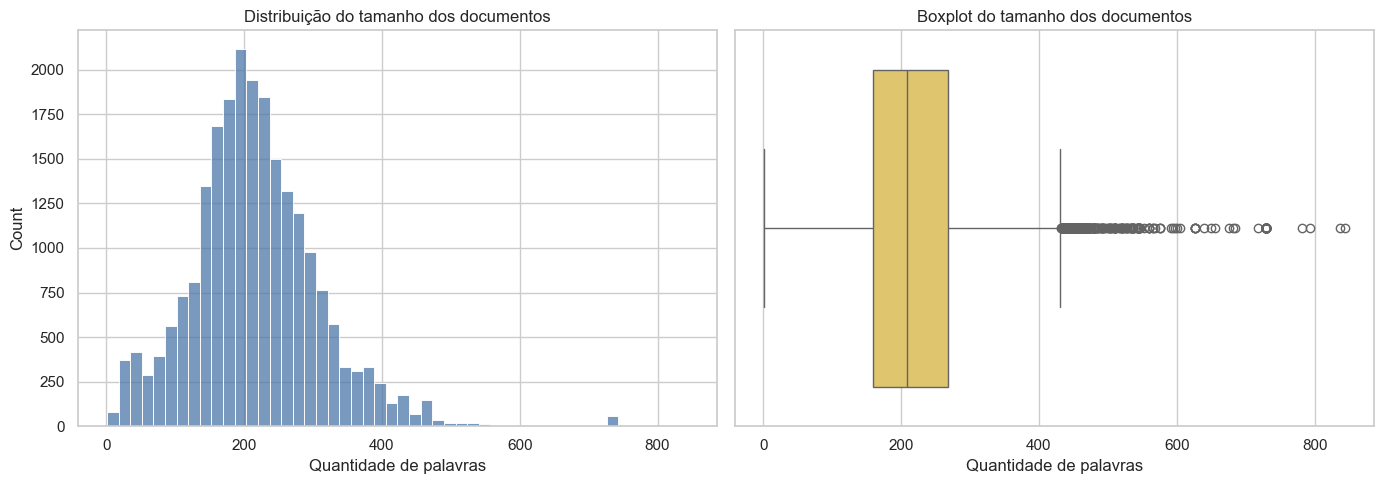

In [76]:
# 1.6 Medidas descritivas do tamanho dos documentos
texto_original = df["Body"].fillna("").astype(str)
df["qtd_caracteres"] = texto_original.str.len()
df["qtd_palavras"] = texto_original.str.split().str.len()
df["qtd_sentencas"] = texto_original.str.count(r"[.!?]+")

display(
    df[["qtd_caracteres", "qtd_palavras", "qtd_sentencas"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["qtd_palavras"], bins=50, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribuição do tamanho dos documentos")
axes[0].set_xlabel("Quantidade de palavras")

sns.boxplot(data=df, x="qtd_palavras", ax=axes[1], color="#F2CF5B")
axes[1].set_title("Boxplot do tamanho dos documentos")
axes[1].set_xlabel("Quantidade de palavras")

plt.tight_layout()
plt.show()


,count,mean,median,std,min,max
Category_nome,,,,,,
Acórdão,665,251.54,262.0,114.34,19,576
Agravo de Recurso Extraordinário (ARE),3529,195.20,181.0,90.09,1,685
Despacho,439,149.04,152.0,102.66,14,844
Recurso Extraordinário (RE),12876,213.88,206.0,87.94,4,781
Sentença,2903,254.39,243.0,94.12,13,837


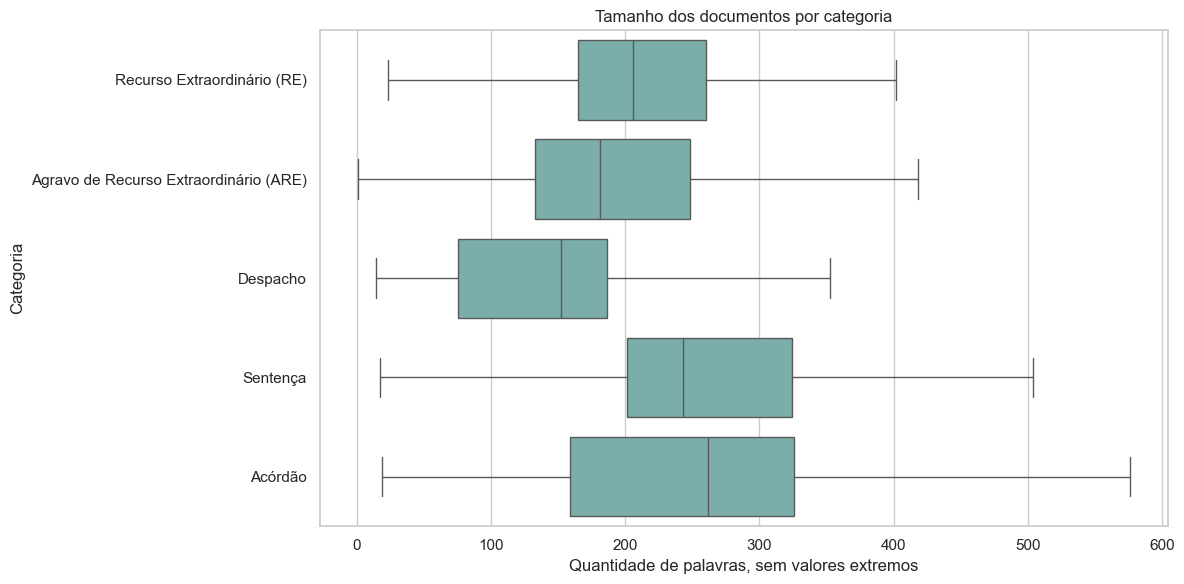

In [77]:
# 1.7 Tamanho dos textos por categoria válida
df_rotulos_validos_eda = df[df["Category"].isin(CLASSES_VALIDAS)].copy()

estatisticas_por_classe = (
    df_rotulos_validos_eda
    .groupby("Category_nome")["qtd_palavras"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)
display(estatisticas_por_classe)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_rotulos_validos_eda,
    y="Category_nome",
    x="qtd_palavras",
    color="#72B7B2",
    showfliers=False,
)
plt.title("Tamanho dos documentos por categoria")
plt.xlabel("Quantidade de palavras, sem valores extremos")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()


,termo,frequencia
0,rio,54583
1,federal,33760
2,ria,29127
3,recurso,27826
4,lei,25684
5,pela,24809
6,geral,23459
7,fazenda,20255
8,benefã,19814
9,contribuiã,19636


Vocabulário observado com min_df=5: 14702 termos


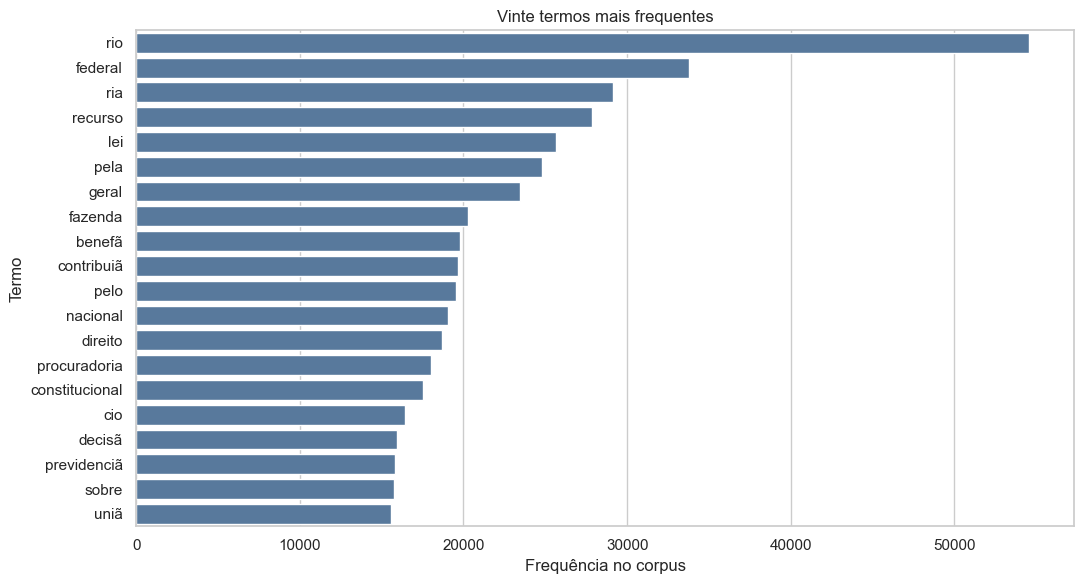

In [78]:
# 1.8 Vocabulário mais frequente no corpus
STOPWORDS_EDA = {
    "a", "o", "os", "as", "um", "uma", "uns", "umas", "de", "do", "da",
    "dos", "das", "em", "no", "na", "nos", "nas", "por", "para", "com",
    "sem", "e", "ou", "mas", "que", "se", "ao", "aos", "é", "são",
    "foi", "ser", "sua", "seu", "suas", "seus", "não", "como", "mais",
    "este", "esta", "esse", "essa", "isso", "lhe", "lhes",
}

vectorizer_eda = CountVectorizer(
    lowercase=True,
    stop_words=list(STOPWORDS_EDA),
    min_df=5,
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ]{3,}\b",
)
X_contagens_eda = vectorizer_eda.fit_transform(texto_original)
termos_eda = np.asarray(
    vectorizer_eda.get_feature_names_out()
    if hasattr(vectorizer_eda, "get_feature_names_out")
    else vectorizer_eda.get_feature_names()
)
frequencias_eda = np.asarray(X_contagens_eda.sum(axis=0)).ravel()

freq_df = (
    pd.DataFrame({"termo": termos_eda, "frequencia": frequencias_eda})
    .sort_values("frequencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_df.head(25))
print(f"Vocabulário observado com min_df=5: {len(termos_eda)} termos")

plt.figure(figsize=(11, 6))
sns.barplot(data=freq_df.head(20), x="frequencia", y="termo", color="#4C78A8")
plt.title("Vinte termos mais frequentes")
plt.xlabel("Frequência no corpus")
plt.ylabel("Termo")
plt.tight_layout()
plt.show()


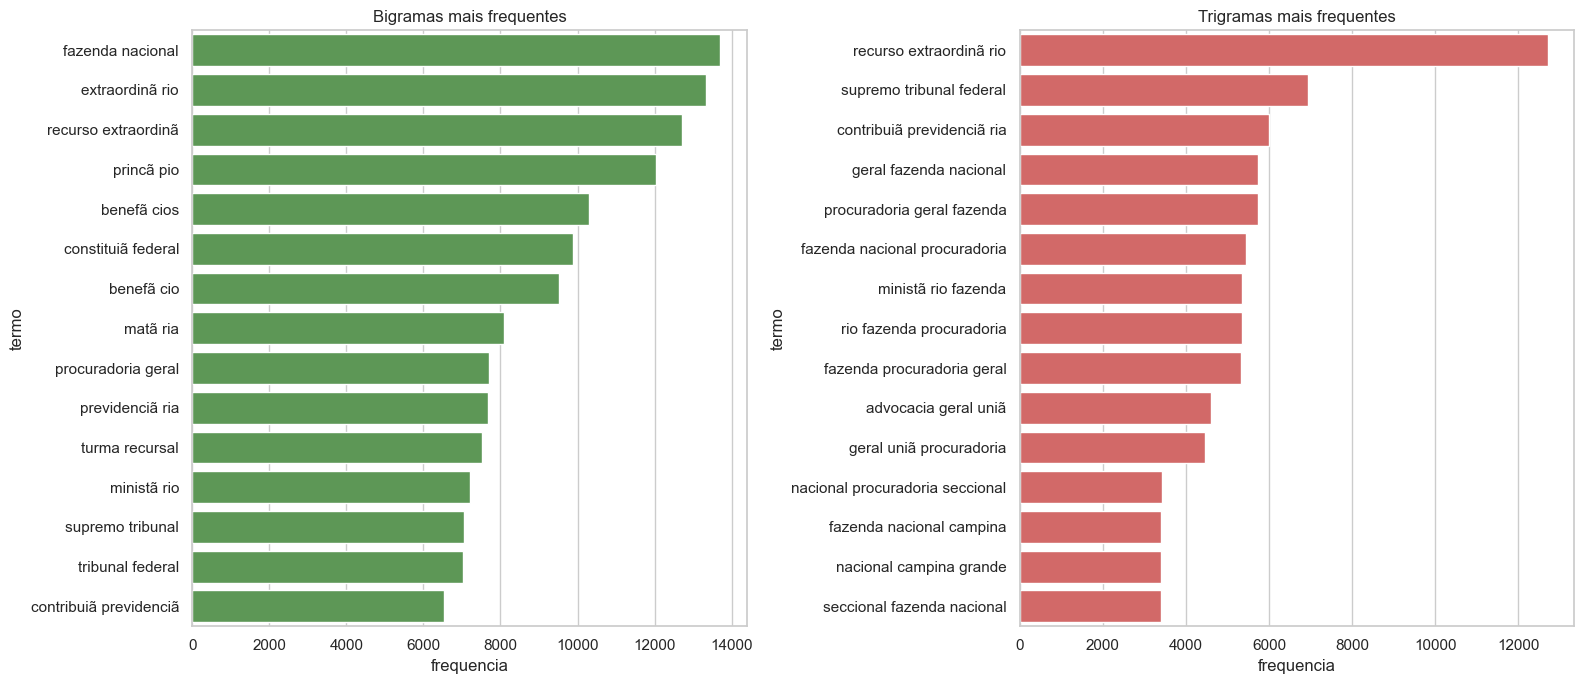

In [79]:
# 1.9 Bigramas e trigramas mais frequentes
def obter_ngramas(textos, intervalo, top_n=15):
    vetorizador = CountVectorizer(
        lowercase=True,
        stop_words=list(STOPWORDS_EDA),
        ngram_range=intervalo,
        min_df=3,
        token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ]{3,}\b",
    )
    matriz = vetorizador.fit_transform(textos)
    termos = np.asarray(
        vetorizador.get_feature_names_out()
        if hasattr(vetorizador, "get_feature_names_out")
        else vetorizador.get_feature_names()
    )
    frequencias = np.asarray(matriz.sum(axis=0)).ravel()
    return (
        pd.DataFrame({"termo": termos, "frequencia": frequencias})
        .sort_values("frequencia", ascending=False)
        .head(top_n)
    )

bigramas = obter_ngramas(texto_original, (2, 2))
trigramas = obter_ngramas(texto_original, (3, 3))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=bigramas, x="frequencia", y="termo", ax=axes[0], color="#54A24B")
axes[0].set_title("Bigramas mais frequentes")
sns.barplot(data=trigramas, x="frequencia", y="termo", ax=axes[1], color="#E45756")
axes[1].set_title("Trigramas mais frequentes")
plt.tight_layout()
plt.show()


**Cinclusões da análise exploratória:** A base contém textos jurídicos longos e heterogêneos, além de documentos sem rótulo (`-1`). A distribuição das classes e a diferença entre os tamanhos dos documentos justificam o uso de divisão estratificada e de métricas macro. Termos e n-gramas recorrentes também indicam que representações baseadas em frequência, como Bag of Words e TF-IDF, constituem baselines adequadas.


---
## 2. Pré-processamento

O pré-processamento busca reduzir ruídos de OCR e padronizar o texto, preservando acentos e palavras jurídicas relevantes. Números são removidos da representação lexical para reduzir números processuais e datas muito específicos; padrões numéricos relevantes serão contabilizados como atributos de extração de informação.

O texto original é mantido na coluna `Body`, enquanto `Body_preprocessado` armazena a versão usada nos modelos.


In [80]:
# 2.1 Stopwords e funções de normalização
import nltk
from nltk.corpus import stopwords as nltk_stopwords

try:
    nltk_stopwords.words("portuguese")
except LookupError:
    nltk.download("stopwords", quiet=True)

# Stopwords manuais (EDA + ajustes finos) combinadas com a lista do NLTK,
# que é mais ampla e cobre variações não previstas manualmente.
STOPWORDS_PT = (
    STOPWORDS_EDA
    | set(nltk_stopwords.words("portuguese"))
    | {
        "sob", "sobre", "entre", "às", "também", "menos", "estes", "estas",
        "esses", "essas", "isto", "aquele", "aquela", "aqueles", "aquelas",
        "me", "te", "vos", "foram", "era", "eram", "estar", "meu", "minha",
        "meus", "minhas", "muito", "muita", "já", "ainda", "então", "após",
        "antes", "quando", "onde", "qual", "quais", "quem", "cujo", "cuja",
        "cujos", "cujas",
    }
)

# Algumas palavras aparentemente funcionais carregam informação no domínio
# jurídico. Esta lista preserva conectores e preposições frequentes em peças,
# decisões e ementas, em vez de removê-los como stopwords comuns.
STOPWORDS_JURIDICAS_PRESERVADAS = {
    "contra", "ante", "sobre", "mediante", "conforme", "perante",
    "segundo", "durante", "sem", "sob", "entre", "após", "apos",
}

STOPWORDS_PT_JURIDICO_REDUZIDAS = (
    set(STOPWORDS_PT) - STOPWORDS_JURIDICAS_PRESERVADAS
)



def normalizar_texto(
    texto,
    remover_numeros=True,
    remover_stopwords=True,
    tamanho_minimo=3,
):
    texto = unicodedata.normalize("NFC", str(texto).lower())
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[_\-]{3,}", " ", texto)

    if remover_numeros:
        texto = re.sub(r"\d+", " ", texto)

    texto = re.sub(r"[^a-záàâãéèêíïóôõöúçñ\s]", " ", texto)
    tokens = re.findall(r"\b[a-záàâãéèêíïóôõöúçñ]+\b", texto)

    if remover_stopwords:
        tokens = [token for token in tokens if token not in STOPWORDS_PT]

    tokens = [token for token in tokens if len(token) >= tamanho_minimo]
    return " ".join(tokens)


def normalizar_texto_stopwords_juridicas(
    texto,
    remover_numeros=True,
    tamanho_minimo=3,
):
    """Remove apenas stopwords menos informativas, preservando conectores jurídicos."""
    texto = unicodedata.normalize("NFC", str(texto).lower())
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[_\-]{3,}", " ", texto)

    if remover_numeros:
        texto = re.sub(r"\d+", " ", texto)

    texto = re.sub(r"[^a-záàâãéèêíïóôõöúçñ\s]", " ", texto)
    tokens = re.findall(r"\b[a-záàâãéèêíïóôõöúçñ]+\b", texto)
    tokens = [
        token for token in tokens
        if token not in STOPWORDS_PT_JURIDICO_REDUZIDAS
    ]
    tokens = [token for token in tokens if len(token) >= tamanho_minimo]
    return " ".join(tokens)


# Lematização com spaCy: reduz a variação morfológica comum no contexto jurídico
# (ex.: "recorrente"/"recorrentes", "provido"/"provida"/"providos") para a
# mesma forma canônica.
LEMATIZAR = False  

if LEMATIZAR:
    import spacy

    try:
        nlp_lema = spacy.load("pt_core_news_sm", disable=["parser", "ner"])
    except OSError:
        from spacy.cli import download as spacy_download

        spacy_download("pt_core_news_sm")
        nlp_lema = spacy.load("pt_core_news_sm", disable=["parser", "ner"])


def normalizar_com_lema(texto, tamanho_minimo=3):
    """Lematiza o texto com spaCy, removendo stopwords e pontuação."""
    doc = nlp_lema(str(texto)[:100000])  # limite por performance
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and len(token.lemma_) >= tamanho_minimo
    ]
    return " ".join(tokens)


In [81]:
# 2.2 Aplicação e verificação do pré-processamento
if LEMATIZAR:
    df["Body_preprocessado"] = df["Body"].map(normalizar_com_lema)
else:
    df["Body_preprocessado"] = df["Body"].map(normalizar_texto)

# Versão alternativa sem remover stopwords.
df["Body_preprocessado_sem_stopwords"] = df["Body"].apply(
    lambda texto: normalizar_texto(
        texto,
        remover_numeros=True,
        remover_stopwords=False,
        tamanho_minimo=3,
    )
)

# Versão intermediária: remove stopwords comuns, mas preserva conectores
# importantes no contexto jurídico.
df["Body_preprocessado_stopwords_juridicas"] = df["Body"].apply(
    lambda texto: normalizar_texto_stopwords_juridicas(
        texto,
        remover_numeros=True,
        tamanho_minimo=3,
    )
)

# Textos eventualmente esvaziados pela limpeza são removidos.
vazios = df["Body_preprocessado"].str.strip().eq("")
print("Textos vazios após o pré-processamento:", int(vazios.sum()))
df = df.loc[~vazios].copy()

df["qtd_palavras_original"] = df["Body"].str.split().str.len()
df["qtd_palavras_preprocessado"] = df["Body_preprocessado"].str.split().str.len()
df["qtd_palavras_sem_stopwords"] = df["Body_preprocessado_sem_stopwords"].str.split().str.len()
df["qtd_palavras_stopwords_juridicas"] = df["Body_preprocessado_stopwords_juridicas"].str.split().str.len()

display(
    df[[
        "qtd_palavras_original",
        "qtd_palavras_preprocessado",
        "qtd_palavras_sem_stopwords",
        "qtd_palavras_stopwords_juridicas",
    ]]
    .describe()
    .round(2)
)

display(df[["Body", "Body_preprocessado", "Body_preprocessado_sem_stopwords", "Body_preprocessado_stopwords_juridicas"]].head(3))


Textos vazios após o pré-processamento: 6


,qtd_palavras_original,qtd_palavras_preprocessado,qtd_palavras_sem_stopwords,qtd_palavras_stopwords_juridicas
count,22674.00,22674.00,22674.00,22674.00
mean,216.48,190.57,222.04,192.13
std,93.03,80.60,95.52,81.36
min,4.00,3.00,3.00,3.00
25%,160.00,142.00,164.00,143.00
50%,209.00,185.00,215.00,186.00
75%,268.00,233.00,275.00,235.00
max,844.00,757.00,901.00,763.00


,Body,Body_preprocessado,Body_preprocessado_sem_stopwords,Body_preprocessado_stopwords_juridicas
0,"{""conclusÃ£o diante exposto recorrente espera ...",conclusã diante exposto recorrente espera conf...,conclusã diante exposto recorrente espera conf...,conclusã diante exposto recorrente espera conf...
1,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",artigo gecen gacen serã devidas titulares empr...,artigo gecen gacen serã devidas aos titulares ...,artigo gecen gacen serã devidas titulares empr...
2,"{""seguir desacerto decisÃ£o que negou seguimen...",seguir desacerto decisã negou seguimento recur...,seguir desacerto decisã que negou seguimento r...,seguir desacerto decisã negou seguimento recur...


---
## 3. Extração de informações jurídicas

Como tarefa básica de PLN, foi implementada uma etapa de **extração de informação (IE)** baseada em padrões. Ela contabiliza referências a artigos, leis, números processuais no padrão CNJ, citações constitucionais e termos associados às partes do processo. Esses atributos permitem testar se sinais estruturais complementam a representação lexical.


In [82]:
# 3.1 Atributos jurídicos extraídos por documento
PADROES_JURIDICOS = {
    "qtd_artigos": r"\bart\.?\s*\d+",
    "qtd_leis": r"\blei\s+(?:n[º°o]\.?\s*)?\d+",
    "qtd_processos_cnj": r"\b\d{7}-\d{2}\.\d{4}\.\d\.\d{2}\.\d{4}\b",
    "qtd_constituicao": r"\b(?:constituição|constitucional|cf[/\s]?88)\b",
    "qtd_recorrente": r"\brecorrente\b",
    "qtd_recorrido": r"\brecorrido\b",
    "qtd_relator": r"\brelator(?:a)?\b",
}

def extrair_atributos_juridicos(textos):
    linhas = []
    for texto in textos.fillna("").astype(str).str.lower():
        atributos = {
            nome: len(re.findall(padrao, texto, flags=re.IGNORECASE))
            for nome, padrao in PADROES_JURIDICOS.items()
        }
        atributos["qtd_caracteres_log"] = np.log1p(len(texto))
        atributos["qtd_palavras_log"] = np.log1p(len(texto.split()))
        linhas.append(atributos)
    return pd.DataFrame(linhas, index=textos.index)

atributos_juridicos = extrair_atributos_juridicos(df["Body"])
display(atributos_juridicos.describe().round(2))


,qtd_artigos,qtd_leis,qtd_processos_cnj,qtd_constituicao,qtd_recorrente,qtd_recorrido,qtd_relator,qtd_caracteres_log,qtd_palavras_log
count,22674.0,22674.0,22674.0,22674.00,22674.00,22674.00,22674.00,22674.00,22674.00
mean,0.0,0.0,0.0,0.77,0.23,0.23,0.27,7.35,5.27
std,0.0,0.0,0.0,1.16,0.65,0.57,0.68,0.56,0.54
min,0.0,0.0,0.0,0.00,0.00,0.00,0.00,3.37,1.61
25%,0.0,0.0,0.0,0.00,0.00,0.00,0.00,7.17,5.08
50%,0.0,0.0,0.0,0.00,0.00,0.00,0.00,7.45,5.35
75%,0.0,0.0,0.0,1.00,0.00,0.00,0.00,7.69,5.59
max,0.0,0.0,0.0,12.00,9.00,9.00,7.00,8.83,6.74


---
## 4. Protocolo experimental e pseudo-rotulagem

Primeiro, somente as amostras com rótulos humanos (`0` a `4`) são divididas em treino e validação. A divisão é feita por grupos de texto idêntico: todas as ocorrências do mesmo conteúdo permanecem no mesmo lado, evitando que uma duplicata no treino facilite artificialmente a classificação de sua cópia na validação. Entre várias divisões candidatas, escolhe-se a que melhor preserva a distribuição global das classes.

Em seguida, um modelo auxiliar treinado apenas na parcela de treino humano estima probabilidades para os documentos `-1`. Somente previsões com confiança mínima são incorporadas ao treino. Esse protocolo evita vazamento de informação e produz uma avaliação mais realista.


In [83]:
# 4.1 Divisão por grupos apenas dos dados rotulados
from sklearn.model_selection import GroupShuffleSplit

TEXT_COL = "Body_preprocessado"
TARGET_COL = "Category"

df_rotulado = df[df[TARGET_COL].isin(CLASSES_VALIDAS)].copy()
df_nao_rotulado = df[df[TARGET_COL].eq(-1)].copy()

distribuicao_global = (
    df_rotulado[TARGET_COL]
    .value_counts(normalize=True)
    .reindex(CLASSES_VALIDAS, fill_value=0)
)

separador = GroupShuffleSplit(
    n_splits=30,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

melhor_divisao = None
melhor_desvio = np.inf

for pos_treino, pos_validacao in separador.split(
    df_rotulado,
    y=df_rotulado[TARGET_COL],
    groups=df_rotulado["Body"],
):
    y_candidato = df_rotulado.iloc[pos_validacao][TARGET_COL]
    if set(y_candidato.unique()) != set(CLASSES_VALIDAS):
        continue

    distribuicao_candidata = (
        y_candidato.value_counts(normalize=True)
        .reindex(CLASSES_VALIDAS, fill_value=0)
    )
    desvio = np.abs(distribuicao_candidata - distribuicao_global).sum()

    if desvio < melhor_desvio:
        melhor_desvio = desvio
        melhor_divisao = (pos_treino, pos_validacao)

if melhor_divisao is None:
    raise RuntimeError("Não foi possível criar uma validação com todas as classes.")

pos_treino, pos_validacao = melhor_divisao
indices_treino = df_rotulado.iloc[pos_treino].index
indices_validacao = df_rotulado.iloc[pos_validacao].index

df_treino_humano = df_rotulado.loc[indices_treino].copy()
df_validacao = df_rotulado.loc[indices_validacao].copy()

print("Treino com rótulos humanos:", df_treino_humano.shape)
print("Validação com rótulos humanos:", df_validacao.shape)
print("Documentos disponíveis para pseudo-rotulagem:", df_nao_rotulado.shape)
print(f"Desvio de distribuição da divisão escolhida: {melhor_desvio:.4f}")
print(
    "Textos compartilhados entre treino e validação:",
    len(set(df_treino_humano["Body"]) & set(df_validacao["Body"])),
)
print("\nClasses na validação:")
print(df_validacao[TARGET_COL].value_counts().sort_index())


Treino com rótulos humanos: (16507, 14)
Validação com rótulos humanos: (3901, 14)
Documentos disponíveis para pseudo-rotulagem: (2266, 14)
Desvio de distribuição da divisão escolhida: 0.0103
Textos compartilhados entre treino e validação: 0

Classes na validação:
Category
0     130
1     691
2      84
3    2452
4     544
Name: count, dtype: int64


In [84]:
# 4.2 Pseudo-rotulagem iterativa com TF-IDF e Regressão Logística
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

LIMIAR_CONFIANCA = 0.80
NUM_RODADAS_PSEUDO = 3  # repete o processo para aproveitar mais dados não rotulados

textos_validacao = set(df_validacao["Body"])
df_nao_rotulado_candidato = df_nao_rotulado[
    ~df_nao_rotulado["Body"].isin(textos_validacao)
].copy()
excluidos_por_validacao = len(df_nao_rotulado) - len(df_nao_rotulado_candidato)

df_treino_atual = df_treino_humano.copy()
lista_pseudo_confiavel = []

for rodada in range(1, NUM_RODADAS_PSEUDO + 1):
    if df_nao_rotulado_candidato.empty:
        print(f"Rodada {rodada}: não há mais candidatos para pseudo-rotulagem.")
        break

    tfidf_pseudo = TfidfVectorizer(
        max_features=40000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        dtype=np.float32,
    )
    X_pseudo_treino = tfidf_pseudo.fit_transform(df_treino_atual[TEXT_COL])
    y_pseudo_treino = df_treino_atual[TARGET_COL]

    modelo_pseudo = LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )
    modelo_pseudo.fit(X_pseudo_treino, y_pseudo_treino)

    X_sem_rotulo = tfidf_pseudo.transform(df_nao_rotulado_candidato[TEXT_COL])
    probabilidades = modelo_pseudo.predict_proba(X_sem_rotulo)

    df_nao_rotulado_candidato["pseudo_Category"] = modelo_pseudo.classes_[
        probabilidades.argmax(axis=1)
    ]
    df_nao_rotulado_candidato["pseudo_confianca"] = probabilidades.max(axis=1)

    mascara_confiavel = (
        df_nao_rotulado_candidato["pseudo_confianca"] >= LIMIAR_CONFIANCA
    )
    pseudo_rodada = df_nao_rotulado_candidato[mascara_confiavel].copy()
    pseudo_rodada[TARGET_COL] = pseudo_rodada["pseudo_Category"].astype(int)

    print(
        f"Rodada {rodada}: {len(pseudo_rodada)} pseudo-rótulos aceitos "
        f"de {len(df_nao_rotulado_candidato)} candidatos."
    )

    if pseudo_rodada.empty:
        print(f"Rodada {rodada}: nenhum pseudo-rótulo atingiu o limiar; encerrando.")
        break

    lista_pseudo_confiavel.append(pseudo_rodada)
    df_treino_atual = pd.concat(
        [df_treino_atual, pseudo_rodada.reindex(columns=df_treino_atual.columns)],
        ignore_index=True,
    )
    df_nao_rotulado_candidato = df_nao_rotulado_candidato.drop(pseudo_rodada.index)

df_pseudo_confiavel = (
    pd.concat(lista_pseudo_confiavel, ignore_index=True)
    if lista_pseudo_confiavel
    else df_nao_rotulado.iloc[0:0].copy()
)

print(f"\nLimiar de confiança: {LIMIAR_CONFIANCA:.0%}")
print(f"Rodadas com pseudo-rótulos aceitos: {len(lista_pseudo_confiavel)} de {NUM_RODADAS_PSEUDO} planejadas")
print("Não rotulados excluídos por coincidirem com a validação:", excluidos_por_validacao)
print("Total de pseudo-rótulos aceitos (todas as rodadas):", len(df_pseudo_confiavel))
print("Candidatos restantes sem rótulo confiável:", len(df_nao_rotulado_candidato))

if not df_pseudo_confiavel.empty:
    display(
        df_pseudo_confiavel[TARGET_COL]
        .value_counts()
        .sort_index()
        .rename(index=MAPA_CLASSES)
        .rename("quantidade")
        .to_frame()
    )


Rodada 1: 1143 pseudo-rótulos aceitos de 2007 candidatos.
Rodada 2: 9 pseudo-rótulos aceitos de 864 candidatos.
Rodada 3: 2 pseudo-rótulos aceitos de 855 candidatos.

Limiar de confiança: 80%
Rodadas com pseudo-rótulos aceitos: 3 de 3 planejadas
Não rotulados excluídos por coincidirem com a validação: 259
Total de pseudo-rótulos aceitos (todas as rodadas): 1154
Candidatos restantes sem rótulo confiável: 853


,quantidade
Category,
Acórdão,58
Agravo de Recurso Extraordinário (ARE),206
Despacho,29
Recurso Extraordinário (RE),627
Sentença,234


### 4.2.1 Sensibilidade do limiar de pseudo-rotulagem

O limiar `0.80` é uma escolha conservadora intermediária. Para avaliar o impacto dessa decisão, a célula abaixo testa limiares alternativos (`0.70`, `0.80` e `0.90`) usando o mesmo conjunto de validação isolado. Essa comparação ajuda a discutir se aceitar mais pseudo-rótulos melhora o desempenho ou apenas adiciona ruído.


In [85]:
# 4.2.1 Comparação de limiares de pseudo-rotulagem
from sklearn.metrics import f1_score
from sklearn.svm import LinearSVC

resultados_limiares_pseudo = []

if not df_nao_rotulado_candidato.empty:
    for limiar in [0.70, 0.80, 0.90]:
        pseudo_limiar = df_nao_rotulado_candidato[
            df_nao_rotulado_candidato["pseudo_confianca"] >= limiar
        ].copy()
        pseudo_limiar[TARGET_COL] = pseudo_limiar["pseudo_Category"].astype(int)

        treino_limiar = pd.concat(
            [
                df_treino_humano,
                pseudo_limiar.reindex(columns=df_treino_humano.columns),
            ],
            ignore_index=True,
        )

        vetor_limiar = TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
            dtype=np.float32,
        )
        X_limiar = vetor_limiar.fit_transform(treino_limiar[TEXT_COL])
        X_val_limiar = vetor_limiar.transform(df_validacao[TEXT_COL])

        modelo_limiar = LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )
        modelo_limiar.fit(X_limiar, treino_limiar[TARGET_COL].astype(int))
        pred_limiar = modelo_limiar.predict(X_val_limiar)

        resultados_limiares_pseudo.append({
            "limiar": limiar,
            "pseudo_rotulos_aceitos": len(pseudo_limiar),
            "macro_f1_validacao": f1_score(
                y_val if "y_val" in globals() else df_validacao[TARGET_COL],
                pred_limiar,
                average="macro",
                zero_division=0,
            ),
        })

    display(
        pd.DataFrame(resultados_limiares_pseudo)
        .sort_values("macro_f1_validacao", ascending=False)
    )
else:
    print("Não há documentos candidatos à pseudo-rotulagem.")


,limiar,pseudo_rotulos_aceitos,macro_f1_validacao
1,0.8,0,0.879848
2,0.9,0,0.879848
0,0.7,202,0.879726


In [86]:
# 4.3 Base expandida: pseudo-rótulos entram somente no treino
colunas_base = df_treino_humano.columns
df_treino_expandido = pd.concat(
    [
        df_treino_humano,
        df_pseudo_confiavel.reindex(columns=colunas_base),
    ],
    ignore_index=True,
)

X_train = df_treino_expandido[TEXT_COL].astype(str)
y_train = df_treino_expandido[TARGET_COL].astype(int)
X_val = df_validacao[TEXT_COL].astype(str)
y_val = df_validacao[TARGET_COL].astype(int)

assert set(y_train.unique()).issubset(CLASSES_VALIDAS)
assert set(y_val.unique()).issubset(CLASSES_VALIDAS)

print("Treino final:", X_train.shape)
print("Validação isolada:", X_val.shape)


Treino final: (17661,)
Validação isolada: (3901,)


---
## 5. Representações computacionais

Nesta parte o texto vira número para os modelos conseguirem treinar.

Foram mantidas as representações que ajudam a comparar pontos diferentes:

1. **Bag of Words:** contagem simples de unigramas e bigramas.
2. **TF-IDF de palavras:** dá mais peso para termos discriminativos.
3. **TF-IDF + atributos jurídicos:** junta texto com sinais extraídos por regex.
4. **TF-IDF + SVD:** cria uma representação densa para a MLP.

Os vetorizadores são ajustados só no treino e aplicados na validação, para evitar vazamento.


In [87]:
# 5.1 Bag of Words e TF-IDF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vectorizer = CountVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    dtype=np.int32,
)
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32,
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print("Bag of Words:", X_train_bow.shape, X_val_bow.shape)
print("TF-IDF:", X_train_tfidf.shape, X_val_tfidf.shape)


Bag of Words: (17661, 30000) (3901, 30000)
TF-IDF: (17661, 50000) (3901, 50000)


In [88]:
# 5.2 Combinação de TF-IDF com atributos jurídicos
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler

atrib_train = extrair_atributos_juridicos(
    df_treino_expandido["Body"]
).to_numpy(dtype=np.float32)
atrib_val = extrair_atributos_juridicos(
    df_validacao["Body"]
).to_numpy(dtype=np.float32)

scaler_atributos = StandardScaler()
atrib_train = scaler_atributos.fit_transform(atrib_train)
atrib_val = scaler_atributos.transform(atrib_val)

X_train_tfidf_ie = hstack(
    [X_train_tfidf, csr_matrix(atrib_train)],
    format="csr",
)
X_val_tfidf_ie = hstack(
    [X_val_tfidf, csr_matrix(atrib_val)],
    format="csr",
)

print("TF-IDF + atributos jurídicos:", X_train_tfidf_ie.shape)


TF-IDF + atributos jurídicos: (17661, 50009)


In [89]:
# 5.3 Representação densa TF-IDF + SVD
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

n_componentes = min(300, X_train_tfidf.shape[0] - 1, X_train_tfidf.shape[1] - 1)
svd = TruncatedSVD(n_components=n_componentes, random_state=RANDOM_STATE)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)

scaler_svd = StandardScaler()
X_train_svd = scaler_svd.fit_transform(X_train_svd).astype(np.float32)
X_val_svd = scaler_svd.transform(X_val_svd).astype(np.float32)

print("Representação densa:", X_train_svd.shape, X_val_svd.shape)
print(f"Variância explicada acumulada: {svd.explained_variance_ratio_.sum():.4f}")


Representação densa: (17661, 300) (3901, 300)
Variância explicada acumulada: 0.5787


---
## 6. Modelos e registro dos experimentos

Aqui ficam só os modelos que ajudam a cumprir o enunciado ou explicam alguma diferença importante:

1. **Modelos clássicos:** Naive Bayes, Regressão Logística e SVM Linear.
2. **Engenharia de atributos:** SVM com TF-IDF + atributos jurídicos.
3. **Modelo neural simples:** MLP com TF-IDF + SVD.
4. **Melhor pipeline clássico:** SVM com TF-IDF de caracteres no texto original.
5. **Teste de pré-processamento:** versões com e sem remoção de stopwords.
6. **Modelos profundos:** TextCNN e BiLSTM.
7. **Transformer:** BERTimbau.

As métricas são registradas aqui. A comparação, gráficos e interpretação ficam na análise dos resultados.


In [90]:
# 6.1 Função de registro
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

resultados = []
predicoes_modelos = {}
modelos_treinados = {}

def registrar_resultado(nome_modelo, representacao, modelo, y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    chave = f"{nome_modelo} - {representacao}"
    resultados.append({
        "modelo": nome_modelo,
        "representacao": representacao,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    })
    predicoes_modelos[chave] = np.asarray(y_pred)
    modelos_treinados[chave] = modelo
    print("Registrado:", chave)


In [91]:
# 6.2 Modelos clássicos com Bag of Words
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

modelos_bow = {
    "Naive Bayes": MultinomialNB(),
    "Regressão Logística": LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    "SVM Linear": LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
}

for nome, modelo in modelos_bow.items():
    modelo.fit(X_train_bow, y_train)
    pred = modelo.predict(X_val_bow)
    registrar_resultado(nome, "Bag of Words", modelo, y_val, pred)


Registrado: Naive Bayes - Bag of Words
Registrado: Regressão Logística - Bag of Words
Registrado: SVM Linear - Bag of Words


/Users/annesakai/Downloads/PLN/template-implementacao/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [92]:
# 6.3 Modelos clássicos com TF-IDF
modelos_tfidf = {
    "Naive Bayes": MultinomialNB(),
    "Regressão Logística": LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    "SVM Linear": LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
}

for nome, modelo in modelos_tfidf.items():
    modelo.fit(X_train_tfidf, y_train)
    pred = modelo.predict(X_val_tfidf)
    registrar_resultado(nome, "TF-IDF", modelo, y_val, pred)


Registrado: Naive Bayes - TF-IDF
Registrado: Regressão Logística - TF-IDF
Registrado: SVM Linear - TF-IDF


In [93]:
# 6.4 SVM com TF-IDF e atributos jurídicos
# Testa se os padrões jurídicos extraídos por regex ajudam além do texto puro.
svm_ie = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
svm_ie.fit(X_train_tfidf_ie, y_train)
pred_svm_ie = svm_ie.predict(X_val_tfidf_ie)

registrar_resultado(
    "SVM Linear",
    "TF-IDF + atributos jurídicos",
    svm_ie,
    y_val,
    pred_svm_ie,
)


Registrado: SVM Linear - TF-IDF + atributos jurídicos


In [94]:
# 6.5 Baseline neural: MLP sobre TF-IDF + SVD
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=4,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_svd, y_train)
pred_mlp = mlp.predict(X_val_svd)

registrar_resultado("MLP", "TF-IDF + SVD", mlp, y_val, pred_mlp)


Registrado: MLP - TF-IDF + SVD


In [95]:
# 6.6 Teste de pré-processamento: stopwords
# Comparação de duas ideias:
# 1) não remover stopwords;
# 2) remover só as stopwords menos úteis, preservando conectores jurídicos.
variacoes_stopwords = [
    ("TF-IDF sem remover stopwords", "Body_preprocessado_sem_stopwords"),
    ("TF-IDF stopwords jurídicas", "Body_preprocessado_stopwords_juridicas"),
]

for nome_representacao, coluna_texto in variacoes_stopwords:
    X_train_stop = df_treino_expandido[coluna_texto].astype(str)
    X_val_stop = df_validacao[coluna_texto].astype(str)

    tfidf_stop = TfidfVectorizer(
        max_features=100000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        dtype=np.float32,
    )
    X_train_stop_tfidf = tfidf_stop.fit_transform(X_train_stop)
    X_val_stop_tfidf = tfidf_stop.transform(X_val_stop)

    for C_stop in [1.0, 2.0]:
        svm_stop = LinearSVC(
            C=C_stop,
            class_weight="balanced",
            max_iter=20000,
            random_state=RANDOM_STATE,
        )
        svm_stop.fit(X_train_stop_tfidf, y_train)
        pred_stop = svm_stop.predict(X_val_stop_tfidf)

        sufixo = "" if C_stop == 1.0 else " C2"
        registrar_resultado(
            "SVM Linear",
            f"{nome_representacao}{sufixo}",
            svm_stop,
            y_val,
            pred_stop,
        )


Registrado: SVM Linear - TF-IDF sem remover stopwords
Registrado: SVM Linear - TF-IDF sem remover stopwords C2
Registrado: SVM Linear - TF-IDF stopwords jurídicas
Registrado: SVM Linear - TF-IDF stopwords jurídicas C2


### 6.8 Modelos profundos: TextCNN e BiLSTM

CNN e BiLSTM recebem sequências de índices de palavras. O vocabulário é construído exclusivamente com o treino, e os textos de validação são apenas transformados. O comprimento máximo limita o custo computacional; documentos maiores são truncados e documentos menores recebem preenchimento.



In [96]:
# 6.8.1 Vocabulário, sequências e utilitários PyTorch
EXECUTAR_MODELOS_PROFUNDOS = True

if EXECUTAR_MODELOS_PROFUNDOS:
    from collections import Counter

    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset

    DISPOSITIVO = (
        "mps"
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
        else "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )
    TAMANHO_VOCABULARIO = 30000
    COMPRIMENTO_MAXIMO = 512
    BATCH_SIZE = 64
    EPOCAS_PROFUNDOS = 3

    contador = Counter(
        token
        for texto in X_train
        for token in str(texto).split()
    )
    vocabulario = {
        token: indice
        for indice, (token, _) in enumerate(
            contador.most_common(TAMANHO_VOCABULARIO - 2),
            start=2,
        )
    }
    PAD_ID, UNK_ID = 0, 1

    def texto_para_sequencia(texto):
        sequencia = [
            vocabulario.get(token, UNK_ID)
            for token in str(texto).split()[:COMPRIMENTO_MAXIMO]
        ]
        return sequencia + [PAD_ID] * (COMPRIMENTO_MAXIMO - len(sequencia))

    class DatasetTextual(Dataset):
        def __init__(self, textos, rotulos):
            self.textos = list(textos)
            self.rotulos = np.asarray(rotulos, dtype=np.int64)

        def __len__(self):
            return len(self.textos)

        def __getitem__(self, indice):
            return (
                torch.tensor(
                    texto_para_sequencia(self.textos[indice]),
                    dtype=torch.long,
                ),
                torch.tensor(self.rotulos[indice], dtype=torch.long),
            )

    dataset_treino = DatasetTextual(X_train, y_train.to_numpy())
    dataset_validacao = DatasetTextual(X_val, y_val.to_numpy())

    loader_treino = DataLoader(
        dataset_treino,
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    loader_validacao = DataLoader(
        dataset_validacao,
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    contagens_classes = np.bincount(y_train, minlength=len(CLASSES_VALIDAS))
    pesos_classes = len(y_train) / (
        len(CLASSES_VALIDAS) * np.maximum(contagens_classes, 1)
    )
    pesos_classes = torch.tensor(
        pesos_classes,
        dtype=torch.float32,
        device=DISPOSITIVO,
    )

    def treinar_modelo_torch(modelo, epocas=3, taxa_aprendizado=1e-3):
        modelo = modelo.to(DISPOSITIVO)
        criterio = nn.CrossEntropyLoss(weight=pesos_classes)
        otimizador = torch.optim.Adam(
            modelo.parameters(),
            lr=taxa_aprendizado,
        )

        for epoca in range(epocas):
            modelo.train()
            perda_acumulada = 0.0

            for sequencias, rotulos in loader_treino:
                sequencias = sequencias.to(DISPOSITIVO)
                rotulos = rotulos.to(DISPOSITIVO)

                otimizador.zero_grad()
                logits = modelo(sequencias)
                perda = criterio(logits, rotulos)
                perda.backward()
                torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
                otimizador.step()
                perda_acumulada += perda.item()

            print(
                f"Época {epoca + 1}/{epocas} - "
                f"perda média: {perda_acumulada / len(loader_treino):.4f}"
            )

        modelo.eval()
        predicoes = []
        with torch.no_grad():
            for sequencias, _ in loader_validacao:
                logits = modelo(sequencias.to(DISPOSITIVO))
                predicoes.extend(logits.argmax(dim=1).cpu().numpy())

        return modelo, np.asarray(predicoes)

    print("Dispositivo:", DISPOSITIVO)
    print("Tamanho do vocabulário:", len(vocabulario) + 2)


Dispositivo: mps
Tamanho do vocabulário: 30000


In [97]:
# 6.8.2 Rede Convolucional para texto (TextCNN)
if EXECUTAR_MODELOS_PROFUNDOS:
    class TextCNN(nn.Module):
        def __init__(
            self,
            tamanho_vocabulario,
            dimensao_embedding=128,
            numero_filtros=128,
            numero_classes=5,
        ):
            super().__init__()
            self.embedding = nn.Embedding(
                tamanho_vocabulario,
                dimensao_embedding,
                padding_idx=PAD_ID,
            )
            self.convolucoes = nn.ModuleList([
                nn.Conv1d(dimensao_embedding, numero_filtros, kernel_size)
                for kernel_size in (3, 4, 5)
            ])
            self.dropout = nn.Dropout(0.4)
            self.saida = nn.Linear(numero_filtros * 3, numero_classes)

        def forward(self, sequencias):
            embeddings = self.embedding(sequencias).transpose(1, 2)
            mapas = [
                torch.relu(convolucao(embeddings)).max(dim=2).values
                for convolucao in self.convolucoes
            ]
            return self.saida(self.dropout(torch.cat(mapas, dim=1)))

    cnn = TextCNN(len(vocabulario) + 2)
    cnn, pred_cnn = treinar_modelo_torch(
        cnn,
        epocas=EPOCAS_PROFUNDOS,
    )

    registrar_resultado(
        "TextCNN",
        "Sequências de tokens",
        cnn,
        y_val,
        pred_cnn,
    )
else:
    print("TextCNN não executada. Defina EXECUTAR_MODELOS_PROFUNDOS=True.")


KeyboardInterrupt: 

In [ ]:
# 6.8.3 Rede recorrente bidirecional (BiLSTM)
if EXECUTAR_MODELOS_PROFUNDOS:
    class BiLSTM(nn.Module):
        def __init__(
            self,
            tamanho_vocabulario,
            dimensao_embedding=128,
            unidades_ocultas=96,
            numero_classes=5,
        ):
            super().__init__()
            self.embedding = nn.Embedding(
                tamanho_vocabulario,
                dimensao_embedding,
                padding_idx=PAD_ID,
            )
            self.lstm = nn.LSTM(
                dimensao_embedding,
                unidades_ocultas,
                batch_first=True,
                bidirectional=True,
            )
            self.dropout = nn.Dropout(0.4)
            self.saida = nn.Linear(unidades_ocultas * 2, numero_classes)

        def forward(self, sequencias):
            embeddings = self.embedding(sequencias)
            _, (estado_oculto, _) = self.lstm(embeddings)
            representacao = torch.cat(
                (estado_oculto[-2], estado_oculto[-1]),
                dim=1,
            )
            return self.saida(self.dropout(representacao))

    bilstm = BiLSTM(len(vocabulario) + 2)
    bilstm, pred_bilstm = treinar_modelo_torch(
        bilstm,
        epocas=EPOCAS_PROFUNDOS,
    )

    registrar_resultado(
        "BiLSTM",
        "Sequências de tokens",
        bilstm,
        y_val,
        pred_bilstm,
    )
else:
    print("BiLSTM não executada. Defina EXECUTAR_MODELOS_PROFUNDOS=True.")


Época 1/3 - perda média: 0.9114
Época 2/3 - perda média: 0.4985
Época 3/3 - perda média: 0.3466
Registrado: BiLSTM - Sequências de tokens


### 6.9 Transformer: BERTimbau
Além dos modelos clássicos e profundos mais simples, também foi incluído um experimento com Transformer usando o BERTimbau (`neuralmind/bert-base-portuguese-cased`). Esse modelo é uma versão do BERT treinada especificamente para a língua portuguesa, o que pode ajudar na classificação dos documentos jurídicos porque ele considera o contexto das palavras, e não apenas a frequência dos termos.

In [ ]:
# 6.10 Fine-tuning manual do BERTimbau
EXECUTAR_BERTIMBAU = False
LIMITE_TREINO_BERT = 1000

if EXECUTAR_BERTIMBAU:
    import torch
    from torch.utils.data import DataLoader, Dataset
    from sklearn.model_selection import train_test_split
    from transformers import (
        AutoModelForSequenceClassification,
        AutoTokenizer,
        get_linear_schedule_with_warmup,
    )

    MODELO_BERTIMBAU = "neuralmind/bert-base-portuguese-cased"
    MAX_LENGTH_BERT = 512
    BATCH_SIZE_BERT = 8
    EPOCAS_BERT = 3

    DISPOSITIVO_BERT = (
        "mps"
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
        else "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    if (
        LIMITE_TREINO_BERT is not None
        and LIMITE_TREINO_BERT < len(df_treino_expandido)
    ):
        _, df_treino_bert = train_test_split(
            df_treino_expandido,
            test_size=LIMITE_TREINO_BERT,
            stratify=df_treino_expandido[TARGET_COL],
            random_state=RANDOM_STATE,
        )
    else:
        df_treino_bert = df_treino_expandido.copy()

    tokenizer_bert = AutoTokenizer.from_pretrained(MODELO_BERTIMBAU)

    def tokenizar_head_tail(texto, tokenizer, max_length):
        """Trunca preservando o início e o final do documento.

        Documentos jurídicos longos costumam trazer o tipo de decisão
        (sentença, acórdão) ao final, que se perderia com um truncamento
        simples pelo início.
        """
        tokens = tokenizer.encode(str(texto), add_special_tokens=False)
        limite_conteudo = max_length - 2  # reserva para [CLS] e [SEP]

        if len(tokens) <= limite_conteudo:
            tokens_selecionados = tokens
        else:
            tamanho_head = 128
            tamanho_tail = limite_conteudo - tamanho_head
            tokens_selecionados = tokens[:tamanho_head] + tokens[-tamanho_tail:]

        return tokenizer(
            str(texto),
            truncation=True,
            max_length=max_length,
            padding=False,
        )

    class DatasetBERT(Dataset):
        def __init__(self, textos, rotulos):
            self.textos = list(textos)
            self.rotulos = list(rotulos)

        def __len__(self):
            return len(self.textos)

        def __getitem__(self, indice):
            codificado = tokenizar_head_tail(
                self.textos[indice],
                tokenizer_bert,
                MAX_LENGTH_BERT,
            )
            item = {
                chave: torch.tensor(valor, dtype=torch.long)
                for chave, valor in codificado.items()
            }
            item["labels"] = torch.tensor(
                self.rotulos[indice],
                dtype=torch.long,
            )
            return item

    def collate_bert(lote):
        rotulos = torch.stack([item.pop("labels") for item in lote])
        lote_preenchido = tokenizer_bert.pad(
            lote,
            padding=True,
            return_tensors="pt",
        )
        lote_preenchido["labels"] = rotulos
        return lote_preenchido

    dataset_treino_bert = DatasetBERT(
        df_treino_bert["Body"],
        df_treino_bert[TARGET_COL],
    )
    dataset_val_bert = DatasetBERT(
        df_validacao["Body"],
        df_validacao[TARGET_COL],
    )

    loader_treino_bert = DataLoader(
        dataset_treino_bert,
        batch_size=BATCH_SIZE_BERT,
        shuffle=True,
        collate_fn=collate_bert,
    )
    loader_val_bert = DataLoader(
        dataset_val_bert,
        batch_size=BATCH_SIZE_BERT,
        shuffle=False,
        collate_fn=collate_bert,
    )

    bertimbau = AutoModelForSequenceClassification.from_pretrained(
        MODELO_BERTIMBAU,
        num_labels=len(CLASSES_VALIDAS),
    ).to(DISPOSITIVO_BERT)

    otimizador_bert = torch.optim.AdamW(
        bertimbau.parameters(),
        lr=2e-5,
        weight_decay=0.01,
    )

    # Scheduler de learning rate com warmup, padrão em fine-tuning de Transformers.
    total_steps_bert = len(loader_treino_bert) * EPOCAS_BERT
    scheduler_bert = get_linear_schedule_with_warmup(
        otimizador_bert,
        num_warmup_steps=total_steps_bert // 10,
        num_training_steps=total_steps_bert,
    )

    for epoca in range(EPOCAS_BERT):
        bertimbau.train()
        perda_acumulada = 0.0

        for lote in loader_treino_bert:
            lote = {
                chave: valor.to(DISPOSITIVO_BERT)
                for chave, valor in lote.items()
            }
            otimizador_bert.zero_grad()
            saida = bertimbau(**lote)
            saida.loss.backward()
            torch.nn.utils.clip_grad_norm_(bertimbau.parameters(), 1.0)
            otimizador_bert.step()
            scheduler_bert.step()
            perda_acumulada += saida.loss.item()

        print(
            f"Época {epoca + 1}/{EPOCAS_BERT} - "
            f"perda média: {perda_acumulada / len(loader_treino_bert):.4f}"
        )

    bertimbau.eval()
    pred_bertimbau = []
    with torch.no_grad():
        for lote in loader_val_bert:
            rotulos = lote.pop("labels")
            lote = {
                chave: valor.to(DISPOSITIVO_BERT)
                for chave, valor in lote.items()
            }
            logits = bertimbau(**lote).logits
            pred_bertimbau.extend(logits.argmax(dim=1).cpu().numpy())

    registrar_resultado(
        "BERTimbau fine-tuned",
        "Transformer",
        bertimbau,
        y_val,
        np.asarray(pred_bertimbau),
    )
else:
    print("BERTimbau não executado. Defina EXECUTAR_BERTIMBAU=True.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

RuntimeError: MPS backend out of memory (MPS allocated: 8.75 GiB, other allocations: 307.73 MiB, max allowed: 9.07 GiB). Tried to allocate 12.00 MiB on shared pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

---
## 7. Análise dos resultados

O **Macro F1** é a métrica principal, pois calcula o F1 de cada classe separadamente e depois atribui o mesmo peso a todas. Acurácia e F1 ponderado são apresentados como métricas complementares. A análise inclui desempenho por classe, matrizes de confusão e o teste de McNemar entre os dois melhores modelos.


In [ ]:
# 7.1 Tabela e ranking dos experimentos
if not resultados:
    raise RuntimeError("Nenhum experimento foi registrado. Execute primeiro a seção 6.")

resultados_df = (
    pd.DataFrame(resultados)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
resultados_df.insert(
    0,
    "experimento",
    resultados_df["modelo"] + " - " + resultados_df["representacao"],
)

display(
    resultados_df.style.format({
        "accuracy": "{:.4f}",
        "precision_macro": "{:.4f}",
        "recall_macro": "{:.4f}",
        "f1_macro": "{:.4f}",
        "f1_weighted": "{:.4f}",
    })
)


,experimento,modelo,representacao,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,SVM Linear - TF-IDF caracteres,SVM Linear,TF-IDF caracteres,0.8823,0.8854,0.8800,0.8821,0.8829
1,SVM Linear - TF-IDF,SVM Linear,TF-IDF,0.8785,0.8812,0.8772,0.8786,0.8793
2,SVM Linear - TF-IDF + atributos jurídicos,SVM Linear,TF-IDF + atributos jurídicos,0.8762,0.8790,0.8784,0.8781,0.8772
3,SVM Linear - TF-IDF max100k C2,SVM Linear,TF-IDF max100k C2,0.8731,0.8827,0.8686,0.8751,0.8738
4,SVM Linear - TF-IDF 1-3 C2,SVM Linear,TF-IDF 1-3 C2,0.8746,0.8796,0.8712,0.8748,0.8759
5,SGD Classifier - TF-IDF,SGD Classifier,TF-IDF,0.8680,0.8828,0.8602,0.8700,0.8701
6,MLP - TF-IDF + SVD,MLP,TF-IDF + SVD,0.8708,0.8709,0.8431,0.8563,0.8700
7,Regressão Logística - TF-IDF,Regressão Logística,TF-IDF,0.8564,0.8331,0.8823,0.8541,0.8603
8,Regressão Logística - Bag of Words,Regressão Logística,Bag of Words,0.8511,0.8458,0.8493,0.8467,0.8533
9,SVM Linear - Bag of Words,SVM Linear,Bag of Words,0.8447,0.8440,0.8362,0.8390,0.8474


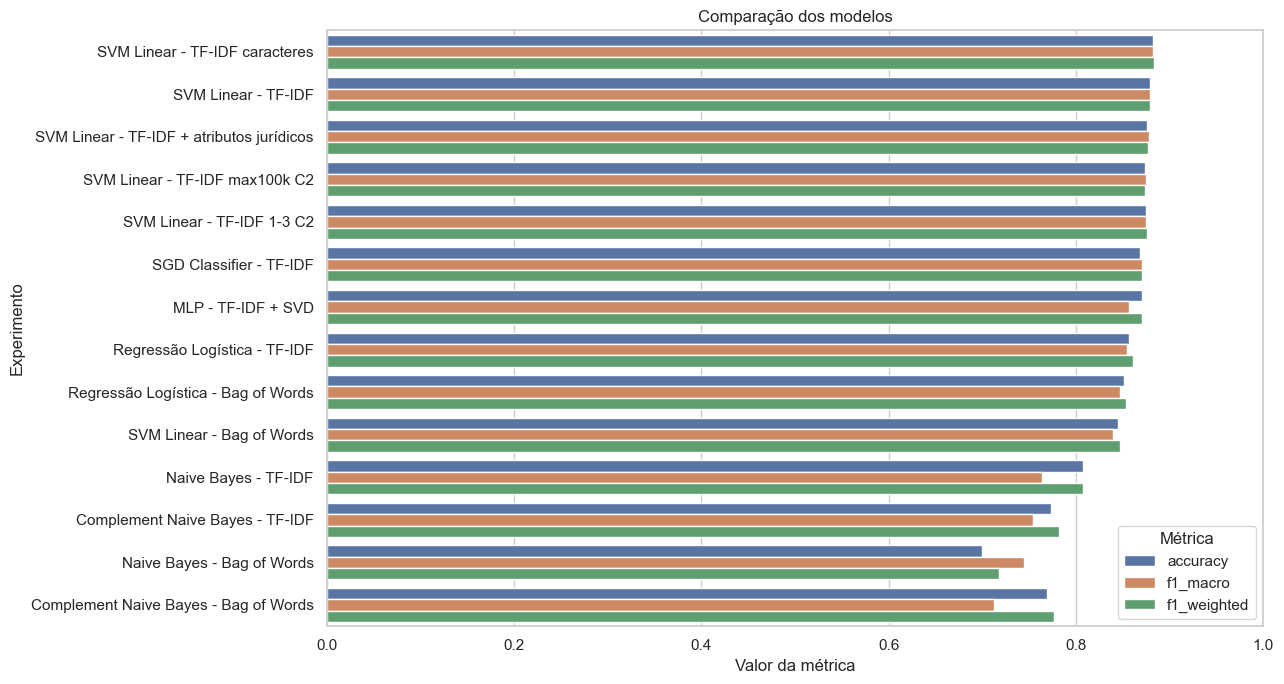

In [ ]:
# 7.2 Comparação visual das métricas
metricas_long = resultados_df.melt(
    id_vars=["experimento"],
    value_vars=["accuracy", "f1_macro", "f1_weighted"],
    var_name="metrica",
    value_name="valor",
)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=metricas_long,
    x="valor",
    y="experimento",
    hue="metrica",
)
plt.title("Comparação dos modelos")
plt.xlabel("Valor da métrica")
plt.ylabel("Experimento")
plt.xlim(0, 1)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()


In [ ]:
# 7.3 Melhor modelo por Macro F1
from sklearn.metrics import classification_report, confusion_matrix

melhor_resultado = resultados_df.iloc[0]
melhor_experimento = melhor_resultado["experimento"]
y_pred_melhor = predicoes_modelos[melhor_experimento]

labels_classes = CLASSES_VALIDAS
nomes_classes = [MAPA_CLASSES[label] for label in labels_classes]

print("Melhor experimento:", melhor_experimento)
print(f"Macro F1: {melhor_resultado['f1_macro']:.4f}")
print(f"Accuracy: {melhor_resultado['accuracy']:.4f}")

relatorio_dict = classification_report(
    y_val,
    y_pred_melhor,
    labels=labels_classes,
    target_names=nomes_classes,
    output_dict=True,
    zero_division=0,
)

metricas_classes = (
    pd.DataFrame(relatorio_dict)
    .T
    .loc[nomes_classes, ["precision", "recall", "f1-score", "support"]]
)
display(metricas_classes.style.format("{:.4f}"))


Melhor experimento: SVM Linear - TF-IDF caracteres
Macro F1: 0.8821
Accuracy: 0.8823


,precision,recall,f1-score,support
Acórdão,0.9237,0.9308,0.9272,130.0000
Agravo de Recurso Extraordinário (ARE),0.7211,0.7482,0.7344,691.0000
Despacho,0.9605,0.8690,0.9125,84.0000
Recurso Extraordinário (RE),0.9214,0.9033,0.9123,2452.0000
Sentença,0.9005,0.9485,0.9239,544.0000


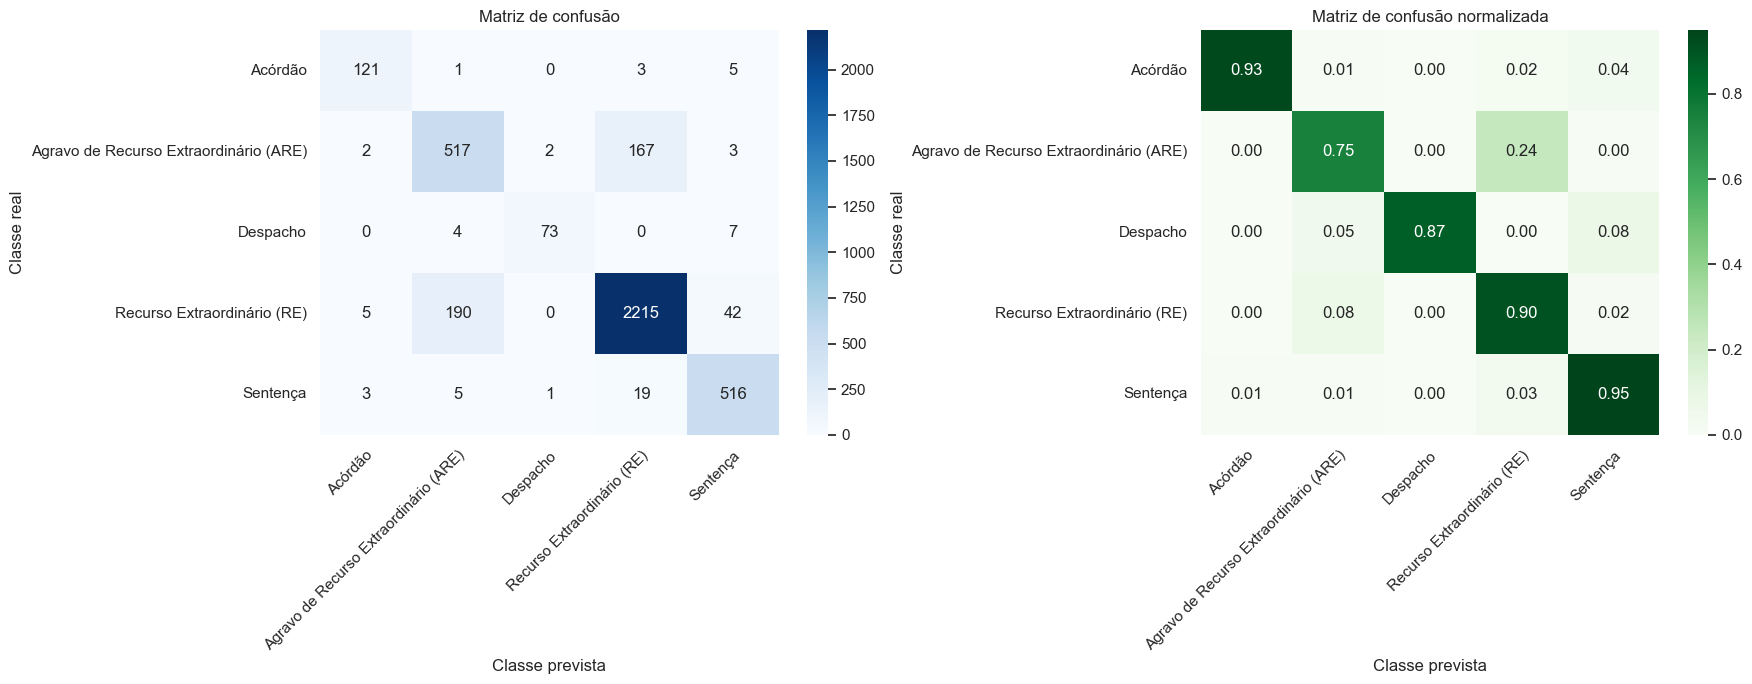

In [ ]:
# 7.4 Matrizes de confusão absoluta e normalizada
matriz_absoluta = confusion_matrix(
    y_val,
    y_pred_melhor,
    labels=labels_classes,
)
matriz_normalizada = confusion_matrix(
    y_val,
    y_pred_melhor,
    labels=labels_classes,
    normalize="true",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(
    matriz_absoluta,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes,
    ax=axes[0],
)
axes[0].set_title("Matriz de confusão")
axes[0].set_xlabel("Classe prevista")
axes[0].set_ylabel("Classe real")

sns.heatmap(
    matriz_normalizada,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes,
    ax=axes[1],
)
axes[1].set_title("Matriz de confusão normalizada")
axes[1].set_xlabel("Classe prevista")
axes[1].set_ylabel("Classe real")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


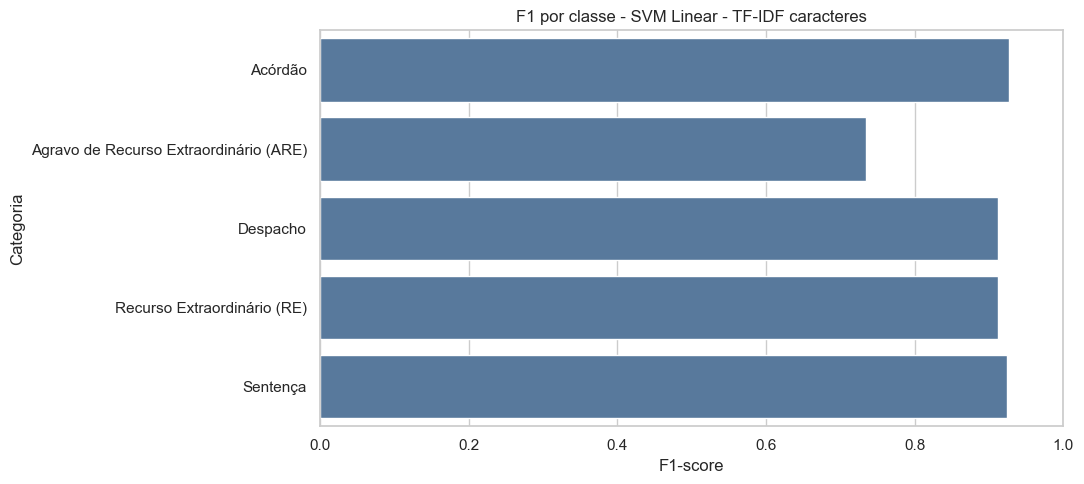

Maior F1 por classe: Acórdão (0.9272)
Menor F1 por classe: Agravo de Recurso Extraordinário (ARE) (0.7344)
Diferença entre accuracy e Macro F1: 0.0003


In [ ]:
# 7.5 F1 por classe e interpretação inicial
metricas_plot = (
    metricas_classes
    .reset_index()
    .rename(columns={"index": "classe", "f1-score": "f1_score"})
)

plt.figure(figsize=(11, 5))
sns.barplot(data=metricas_plot, x="f1_score", y="classe", color="#4C78A8")
plt.title(f"F1 por classe - {melhor_experimento}")
plt.xlabel("F1-score")
plt.ylabel("Categoria")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

classe_mais_dificil = metricas_plot.loc[metricas_plot["f1_score"].idxmin()]
classe_mais_facil = metricas_plot.loc[metricas_plot["f1_score"].idxmax()]

print(
    f"Maior F1 por classe: {classe_mais_facil['classe']} "
    f"({classe_mais_facil['f1_score']:.4f})"
)
print(
    f"Menor F1 por classe: {classe_mais_dificil['classe']} "
    f"({classe_mais_dificil['f1_score']:.4f})"
)

diferenca = melhor_resultado["accuracy"] - melhor_resultado["f1_macro"]
print(f"Diferença entre accuracy e Macro F1: {diferenca:.4f}")
if diferenca > 0.05:
    print(
        "A diferença sugere desempenho menos uniforme entre as classes; "
        "a matriz de confusão deve orientar a discussão dos erros."
    )


In [ ]:
# 7.6 Teste de McNemar entre os dois melhores experimentos
import scipy.stats as stats

if len(resultados_df) >= 2:
    exp_1, exp_2 = resultados_df.loc[:1, "experimento"]
    pred_1 = predicoes_modelos[exp_1]
    pred_2 = predicoes_modelos[exp_2]

    correto_1 = pred_1 == y_val.to_numpy()
    correto_2 = pred_2 == y_val.to_numpy()
    b = int(np.sum(correto_1 & ~correto_2))
    c = int(np.sum(~correto_1 & correto_2))

    if b + c == 0:
        print("Os dois modelos acertaram e erraram exatamente os mesmos documentos.")
    else:
        if hasattr(stats, "binomtest"):
            p_valor = stats.binomtest(min(b, c), n=b + c, p=0.5).pvalue
        else:
            p_valor = stats.binom_test(min(b, c), n=b + c, p=0.5)
        print("Modelo 1:", exp_1)
        print("Modelo 2:", exp_2)
        print(f"Modelo 1 acertou / Modelo 2 errou: {b}")
        print(f"Modelo 1 errou / Modelo 2 acertou: {c}")
        print(f"p-valor do teste exato de McNemar: {p_valor:.4f}")
        print(
            "Diferença estatisticamente significativa."
            if p_valor < 0.05
            else "Não há evidência de diferença estatisticamente significativa."
        )


Modelo 1: SVM Linear - TF-IDF caracteres
Modelo 2: SVM Linear - TF-IDF
Modelo 1 acertou / Modelo 2 errou: 84
Modelo 1 errou / Modelo 2 acertou: 69
p-valor do teste exato de McNemar: 0.2576
Não há evidência de diferença estatisticamente significativa.


Calculando curva de aprendizado (isso pode demorar um pouco)...


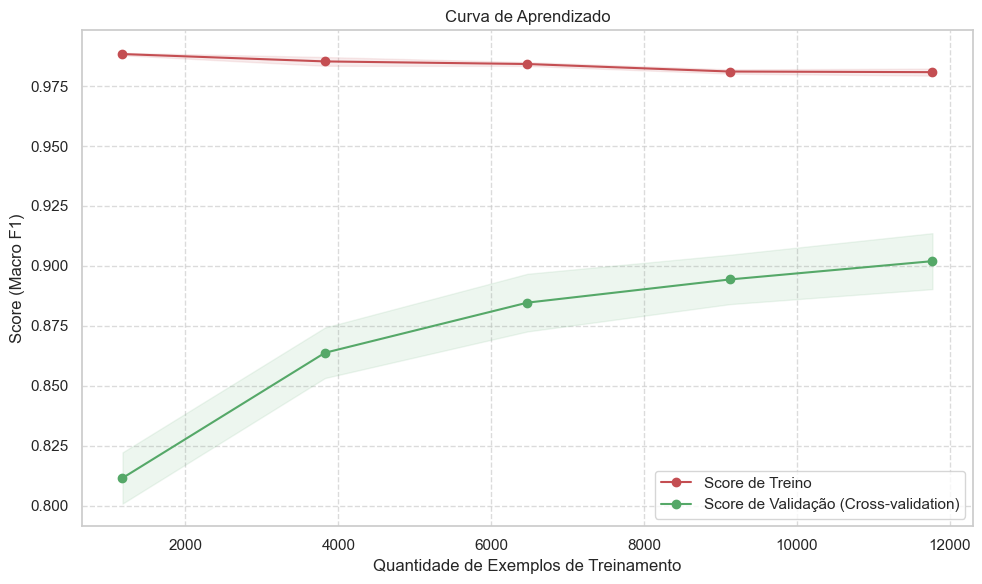

In [ ]:
# 7.7 Curva de Aprendizado do melhor modelo
from sklearn.model_selection import learning_curve

def plot_curva_aprendizado(estimator, X, y, cv=3, title="Curva de Aprendizado"):
    """
    Gera e plota a curva de aprendizado de um modelo.
    """
    train_sizes_param = np.linspace(0.1, 1.0, 5)
    
    print("Calculando curva de aprendizado")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, 
        X, 
        y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes_param, 
        scoring='f1_macro'
    )
    
    # Calcula as médias e desvios padrões
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plotagem
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Quantidade de Exemplos de Treinamento")
    plt.ylabel("Score (Macro F1)")
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plota a sombra do desvio padrão (variância do modelo)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Plota as linhas médias
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score de Treino")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score de Validação (Cross-validation)")

    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_curva_aprendizado(modelos_tfidf["SVM Linear"], X_train_tfidf, y_train)

---
## 8. Treinamento final e submissão

Após selecionar o melhor experimento pela validação, o modelo é recriado e treinado com todos os documentos rotulados mais os pseudo-rótulos confiáveis. O `test.csv` recebe exatamente o mesmo pré-processamento. A submissão contém somente `Id` e `Category`, e uma validação impede o envio de `-1` ou de qualquer classe inesperada.


In [ ]:
# 8.1 Preparação da base completa para o treinamento final
from sklearn.base import clone

if not CAMINHO_TESTE.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {CAMINHO_TESTE.resolve()}")

test = pd.read_csv(CAMINHO_TESTE)
if not {"Id", "Body"}.issubset(test.columns):
    raise ValueError("O test.csv deve conter as colunas Id e Body.")

test["Body"] = test["Body"].fillna("").astype(str)
test[TEXT_COL] = test["Body"].map(normalizar_texto)

df_rotulado_completo = df[df[TARGET_COL].isin(CLASSES_VALIDAS)].copy()

# Para a submissão, a pseudo-rotulagem pode usar todos os rótulos humanos.
tfidf_pseudo_final = clone(tfidf_pseudo)
modelo_pseudo_final = clone(modelo_pseudo)
X_rotulado_final = tfidf_pseudo_final.fit_transform(
    df_rotulado_completo[TEXT_COL]
)
modelo_pseudo_final.fit(
    X_rotulado_final,
    df_rotulado_completo[TARGET_COL],
)

df_pseudo_final = df_nao_rotulado.iloc[0:0].copy()
if not df_nao_rotulado.empty:
    prob_final = modelo_pseudo_final.predict_proba(
        tfidf_pseudo_final.transform(df_nao_rotulado[TEXT_COL])
    )
    df_nao_rotulado_final = df_nao_rotulado.copy()
    df_nao_rotulado_final["pseudo_confianca"] = prob_final.max(axis=1)
    df_nao_rotulado_final[TARGET_COL] = modelo_pseudo_final.classes_[
        prob_final.argmax(axis=1)
    ]
    df_pseudo_final = df_nao_rotulado_final[
        df_nao_rotulado_final["pseudo_confianca"] >= LIMIAR_CONFIANCA
    ].copy()

df_modelagem_final = pd.concat(
    [df_rotulado_completo, df_pseudo_final.reindex(columns=df.columns)],
    ignore_index=True,
)

X_final_texto = df_modelagem_final[TEXT_COL].astype(str)
y_final = df_modelagem_final[TARGET_COL].astype(int)
X_submission_texto = test[TEXT_COL].astype(str)

print("Melhor experimento:", melhor_experimento)
print("Amostras no treino final:", len(df_modelagem_final))


Melhor experimento: SVM Linear - TF-IDF palavras + caracteres v2
Amostras no treino final: 21769


In [ ]:
# 8.2 Recriação da representação e do melhor modelo
representacoes_elegiveis_submission = {
    "Bag of Words",
    "TF-IDF",
    "TF-IDF + atributos jurídicos",
    "TF-IDF + SVD",
    "TF-IDF caracteres raw 4-6",
    "TF-IDF sem remover stopwords",
    "TF-IDF sem remover stopwords C2",
    "TF-IDF stopwords jurídicas",
    "TF-IDF stopwords jurídicas C2",
}

modelos_elegiveis_submission = {
    "Naive Bayes",
    "Regressão Logística",
    "SVM Linear",
    "MLP",
}

resultados_elegiveis = resultados_df[
    resultados_df["modelo"].isin(modelos_elegiveis_submission)
    & resultados_df["representacao"].isin(representacoes_elegiveis_submission)
].copy()

if resultados_elegiveis.empty:
    raise RuntimeError("Não há modelo elegível para gerar a submissão.")

melhor_resultado_submission = resultados_elegiveis.iloc[0]
nome_modelo = melhor_resultado_submission["modelo"]
representacao = melhor_resultado_submission["representacao"]

print(
    "Modelo selecionado para a submissão:",
    f"{nome_modelo} - {representacao}",
)


def criar_modelo(nome, representacao_atual):
    if nome == "Naive Bayes":
        return MultinomialNB()
    if nome == "Regressão Logística":
        return LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        )
    if nome == "SVM Linear":
        C_final = 2.0 if ("C2" in representacao_atual or "raw 4-6" in representacao_atual) else 1.0
        return LinearSVC(
            C=C_final,
            class_weight="balanced",
            max_iter=20000,
            random_state=RANDOM_STATE,
        )
    if nome == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            solver="adam",
            batch_size=64,
            learning_rate_init=0.001,
            max_iter=30,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=4,
            random_state=RANDOM_STATE,
        )
    raise ValueError(f"Modelo não reconhecido: {nome}")


def gerar_matriz_final(representacao_atual):
    if representacao_atual == "Bag of Words":
        vetor = clone(bow_vectorizer)
        return (
            vetor.fit_transform(X_final_texto),
            vetor.transform(X_submission_texto),
        )

    if representacao_atual == "TF-IDF caracteres raw 4-6":
        vetor = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(4, 6),
            min_df=2,
            max_features=150000,
            sublinear_tf=True,
            lowercase=True,
            dtype=np.float32,
        )
        return (
            vetor.fit_transform(df_modelagem_final["Body"].astype(str)),
            vetor.transform(test["Body"].astype(str)),
        )

    if representacao_atual in {"TF-IDF sem remover stopwords", "TF-IDF sem remover stopwords C2"}:
        texto_final_sem_stop = df_modelagem_final["Body"].apply(
            lambda texto: normalizar_texto(
                texto,
                remover_numeros=True,
                remover_stopwords=False,
                tamanho_minimo=3,
            )
        )
        texto_submission_sem_stop = test["Body"].apply(
            lambda texto: normalizar_texto(
                texto,
                remover_numeros=True,
                remover_stopwords=False,
                tamanho_minimo=3,
            )
        )
        vetor = TfidfVectorizer(
            max_features=100000,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
            dtype=np.float32,
        )
        return (
            vetor.fit_transform(texto_final_sem_stop),
            vetor.transform(texto_submission_sem_stop),
        )

    if representacao_atual in {"TF-IDF stopwords jurídicas", "TF-IDF stopwords jurídicas C2"}:
        texto_final_juridico = df_modelagem_final["Body"].apply(
            lambda texto: normalizar_texto_stopwords_juridicas(
                texto,
                remover_numeros=True,
                tamanho_minimo=3,
            )
        )
        texto_submission_juridico = test["Body"].apply(
            lambda texto: normalizar_texto_stopwords_juridicas(
                texto,
                remover_numeros=True,
                tamanho_minimo=3,
            )
        )
        vetor = TfidfVectorizer(
            max_features=100000,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
            dtype=np.float32,
        )
        return (
            vetor.fit_transform(texto_final_juridico),
            vetor.transform(texto_submission_juridico),
        )

    vetor = clone(tfidf_vectorizer)
    X_final_tfidf = vetor.fit_transform(X_final_texto)
    X_submission_tfidf = vetor.transform(X_submission_texto)

    if representacao_atual == "TF-IDF":
        return X_final_tfidf, X_submission_tfidf

    if representacao_atual == "TF-IDF + atributos jurídicos":
        scaler_final = clone(scaler_atributos)
        atributos_final = extrair_atributos_juridicos(
            df_modelagem_final["Body"]
        ).to_numpy(dtype=np.float32)
        atributos_submission = extrair_atributos_juridicos(
            test["Body"]
        ).to_numpy(dtype=np.float32)
        atributos_final = scaler_final.fit_transform(atributos_final)
        atributos_submission = scaler_final.transform(atributos_submission)
        return (
            hstack([X_final_tfidf, csr_matrix(atributos_final)], format="csr"),
            hstack([X_submission_tfidf, csr_matrix(atributos_submission)], format="csr"),
        )

    if representacao_atual == "TF-IDF + SVD":
        n_comp_final = min(
            300,
            X_final_tfidf.shape[0] - 1,
            X_final_tfidf.shape[1] - 1,
        )
        svd_final = TruncatedSVD(
            n_components=n_comp_final,
            random_state=RANDOM_STATE,
        )
        scaler_final = StandardScaler()
        return (
            scaler_final.fit_transform(
                svd_final.fit_transform(X_final_tfidf)
            ).astype(np.float32),
            scaler_final.transform(
                svd_final.transform(X_submission_tfidf)
            ).astype(np.float32),
        )

    raise ValueError(f"Representação não reconhecida: {representacao_atual}")


modelo_final = criar_modelo(nome_modelo, representacao)
X_final, X_submission = gerar_matriz_final(representacao)
modelo_final.fit(X_final, y_final)
predicoes_submission = modelo_final.predict(X_submission).astype(int)


In [ ]:
# 8.3 Validação e gravação da submissão
classes_invalidas = set(np.unique(predicoes_submission)) - set(CLASSES_VALIDAS)
if classes_invalidas:
    raise ValueError(f"A submissão contém classes inválidas: {classes_invalidas}")

submission = pd.DataFrame({
    "Id": test["Id"].to_numpy(),
    "Category": predicoes_submission,
})

if len(submission) != len(test):
    raise ValueError("A quantidade de previsões não corresponde ao test.csv.")
if submission["Id"].duplicated().any():
    raise ValueError("A submissão contém IDs duplicados.")

submission.to_csv(CAMINHO_SUBMISSION, index=False)

display(submission.head())
print("Dimensão:", submission.shape)
print("Distribuição das previsões:")
print(submission["Category"].value_counts().sort_index())
print(f"Arquivo salvo em: {CAMINHO_SUBMISSION.resolve()}")


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


Dimensão: (2521, 2)
Distribuição das previsões:
Category
0      78
1     448
2      49
3    1613
4     333
Name: count, dtype: int64
Arquivo salvo em: /content/drive/MyDrive/Projeto_PLN/submission.csv
